In [3]:
import os
import json
import numpy as np
import pandas as pd
import astropy.coordinates as coord
import astropy.units as u
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from astropy.table import Table

%matplotlib inline
%config InlineBackend.figure_format = "retina"
from matplotlib import rcParams
rcParams['savefig.dpi'] = 550
rcParams['font.size'] = 20
plt.rc('font', family='serif')

%matplotlib inline

In [4]:
from utils_ztf import get_cookie,download_ZTF
from utils_ztf import BaryCorr,LC_normalize
from utils_ztf import calc_lsp,optimize_freq
from utils_ztf import PhaseFold,PhaseFoldBinned
from utils_ztf import GaiaQuery,lighten_color

In [5]:
USER = "atzanida@uw.edu"
PASS = "Kepler314**"

In [5]:
# Search Coordinates and search radius
radec = ['19 27 38.30', '+34 11 41.80']
radius = 3.0 # arcseconds

if isinstance(radec[0],float):
    c = coord.SkyCoord(
        ra=radec[0], 
        dec=radec[1], 
        unit=(u.deg,u.deg),
        frame='icrs'
    )
if isinstance(radec[0],str):
    c = coord.SkyCoord(
        ra=radec[0], 
        dec=radec[1],
        unit=(u.hourangle,u.deg), 
        frame='icrs'
    )
ra = c.ra.deg # Search RA
dec = c.dec.deg # Search Dec

In [7]:
%%time 
# Perform ZTF query
cookie = get_cookie(USER,PASS)

CPU times: user 45.9 ms, sys: 4.53 ms, total: 50.5 ms
Wall time: 243 ms


In [8]:
import concurrent.futures

In [192]:
M = np.load("/Users/andytzanidakis/Desktop/ztf_pointings_test.npy")

In [ ]:
%%time
def download_ZTF_parallel(coordinates, radius, cookie, release):
    ra, dec = coordinates
    return download_ZTF(ra, dec, radius=radius, irsa_cookie=cookie, release=release)

coordinates = list(zip(M[:,0],
                       M[:,1]))

release = 20  # Set your release value
radius = 3
with concurrent.futures.ThreadPoolExecutor(max_workers=100) as executor:
    # Use map to apply the function to each set of coordinates in parallel
    results = list(executor.map(download_ZTF_parallel, coordinates, [radius] * len(coordinates), [cookie] * len(coordinates), [release] * len(coordinates)))

# results contains the data for each set of coordinates

In [9]:
release = 20  # Set your release value
radius = 3

In [81]:
%%time
data = download_ZTF(60.41566, 44.81696,
    radius=radius, 
    irsa_cookie=cookie, 
    release=20)

CPU times: user 189 ms, sys: 34.7 ms, total: 224 ms
Wall time: 4.34 s


In [84]:
f = (data['filtercode']=='zr')& (data['catflags']==0) & (data['chi']<1) & (abs(data['sharp'])<0.25)
f2 = (data['filtercode']=='zg' )& (data['catflags']==0) & (data['chi']<1) & (abs(data['sharp'])<0.25)
f3 = (data['filtercode']=='zi' )& (data['catflags']==0) & (data['chi']<1) & (abs(data['sharp'])<0.25)

<ErrorbarContainer object of 3 artists>

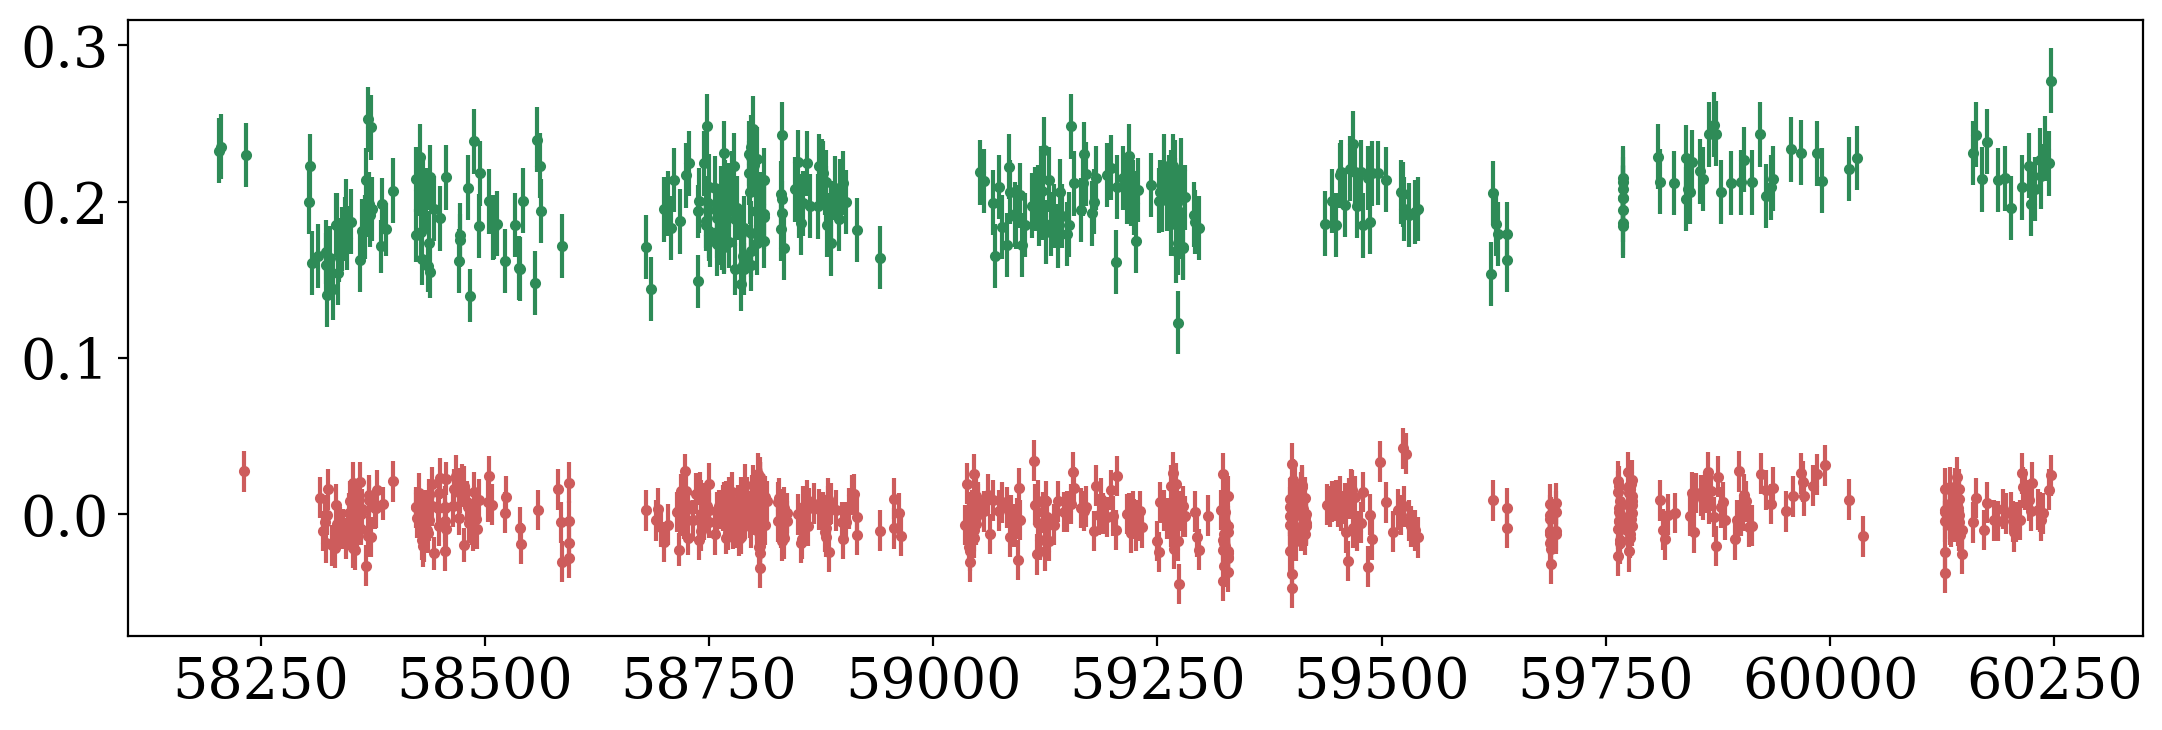

In [85]:
plt.figure(figsize=(13, 4))
plt.errorbar(data[f]['mjd'], data[f]['mag']-np.median(data[f]['mag']), data[f]['magerr'], 
            fmt='.', color='indianred')

plt.errorbar(data[f2]['mjd'], 0.2 + data[f2]['mag']-np.median(data[f2]['mag']), data[f2]['magerr'], 
            fmt='.', color='seagreen')

plt.errorbar(data[f3]['mjd'], -0.2 + data[f3]['mag']-np.median(data[f3]['mag']), data[f3]['magerr'], 
            fmt='.', color='#333333')

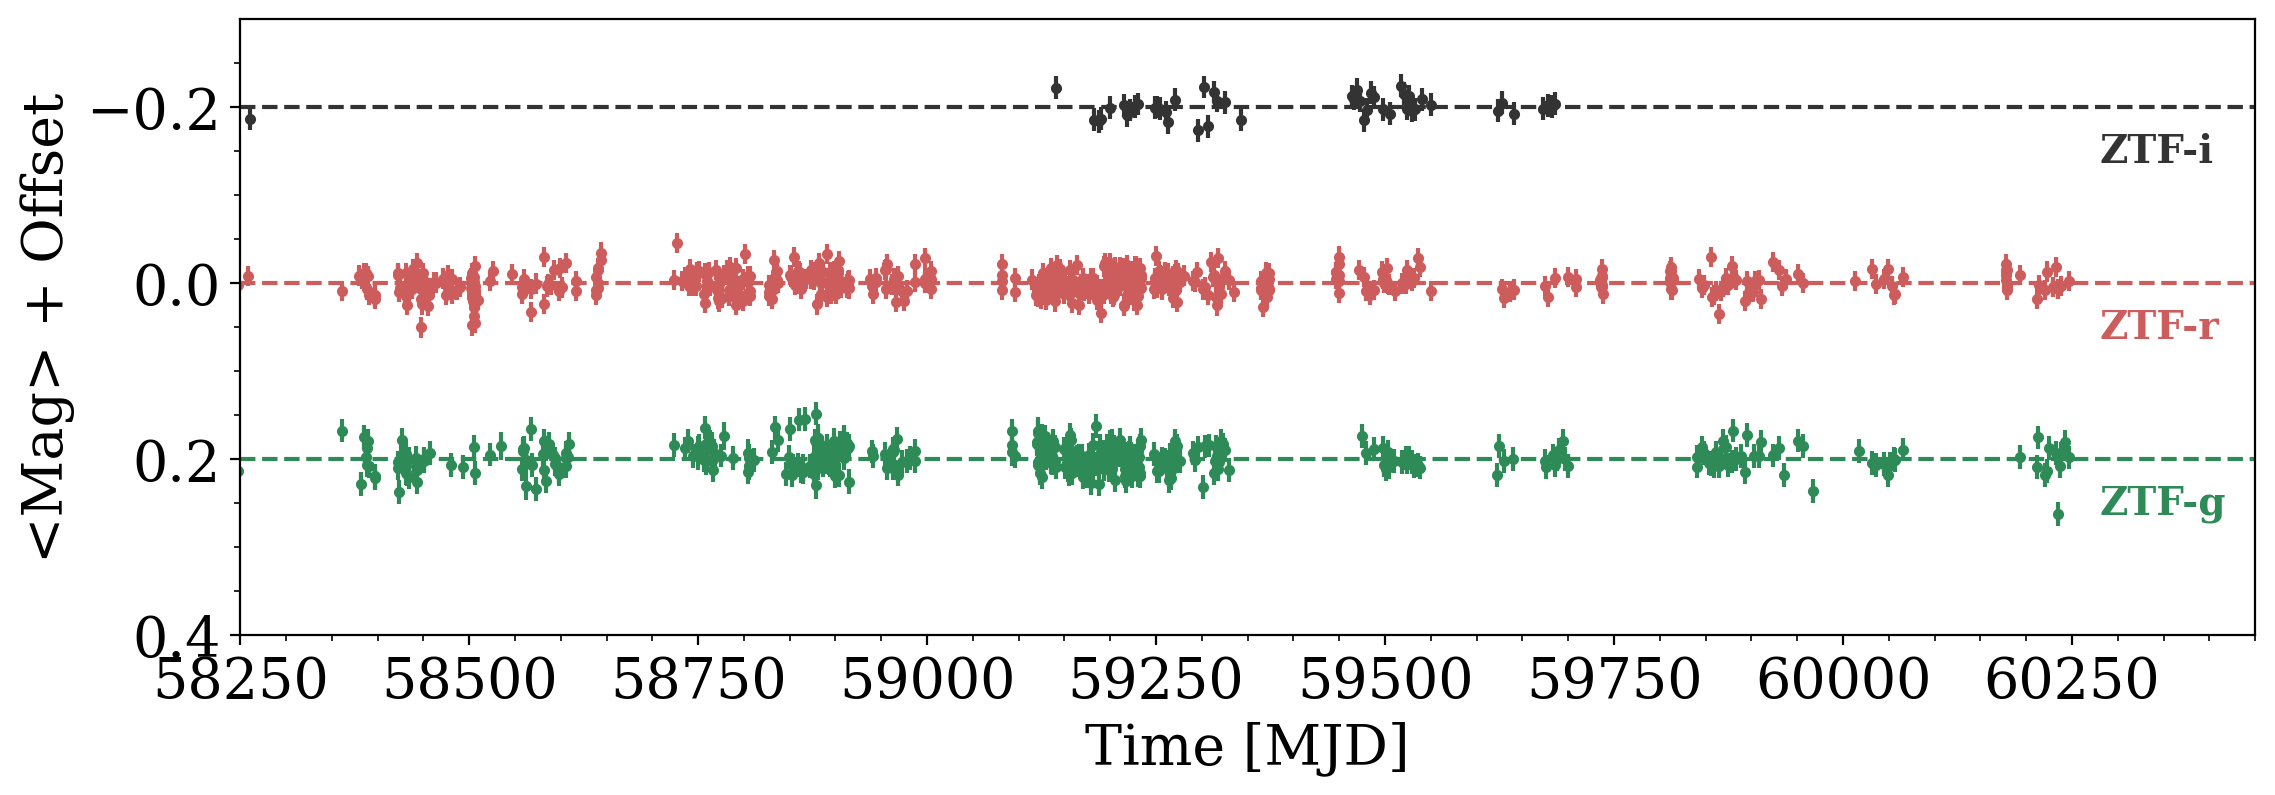

In [12]:
plt.figure(figsize=(13, 4))
plt.errorbar(data[f]['mjd'], data[f]['mag']-np.median(data[f]['mag']), data[f]['magerr'], 
            fmt='.', color='indianred')

plt.errorbar(data[f2]['mjd'], 0.2 + data[f2]['mag']-np.median(data[f2]['mag']), data[f2]['magerr'], 
            fmt='.', color='seagreen')

plt.errorbar(data[f3]['mjd'], -0.2 + data[f3]['mag']-np.median(data[f3]['mag']), data[f3]['magerr'], 
            fmt='.', color='#333333')

# Plot dashed horizontal line for the mean of [f] dataset
mean_f = np.mean(data[f]['mag']-np.median(data[f]['mag']))
plt.axhline(mean_f, linestyle='--', color='indianred', label='Mean [f]')

# Plot dashed horizontal line for the mean of [f2] dataset
mean_f2 = np.mean(0.2 + data[f2]['mag']-np.median(data[f2]['mag']))
plt.axhline(mean_f2, linestyle='--', color='seagreen', label='Mean [f2]')

# Plot dashed horizontal line for the mean of [f3] dataset
mean_f3 = np.mean(-0.2 + data[f3]['mag']-np.median(data[f3]['mag']))
plt.axhline(mean_f3, linestyle='--', color='#333333', label='Mean [f3]')


# Add labels at the far right
plt.text(60_280,0.05, 'ZTF-r', color='indianred', va='center', ha='left', fontweight='bold', fontsize=14)
plt.text(60_280, 0.2 + 0.05, 'ZTF-g', color='seagreen', va='center', ha='left', fontweight='bold', fontsize=14)
plt.text(60_280, -0.2 + 0.05, 'ZTF-i', color='#333333', va='center', ha='left', fontweight='bold', fontsize=14)



#plt.text(max(data[f2]['mjd']) + 0.1, mean_f2, 'ztf-g (for f2)', color='seagreen', va='center', ha='left', fontweight='bold')
#plt.text(max(data[f3]['mjd']) + 0.1, mean_f3, 'ztf-i (for f3)', color='#333333', va='center', ha='left', fontweight='bold')


plt.xlim(58_500-250, 60_300+150)
plt.ylim(plt.ylim(-0.3, 0.4)[::-1])
plt.ylabel("<Mag> + Offset")
plt.xlabel("Time [MJD]")
plt.minorticks_on()


In [103]:
from gaiaxpy import calibrate

In [106]:
f = "spe.csv"

In [107]:
calibrated_spectra, sampling = calibrate(f)

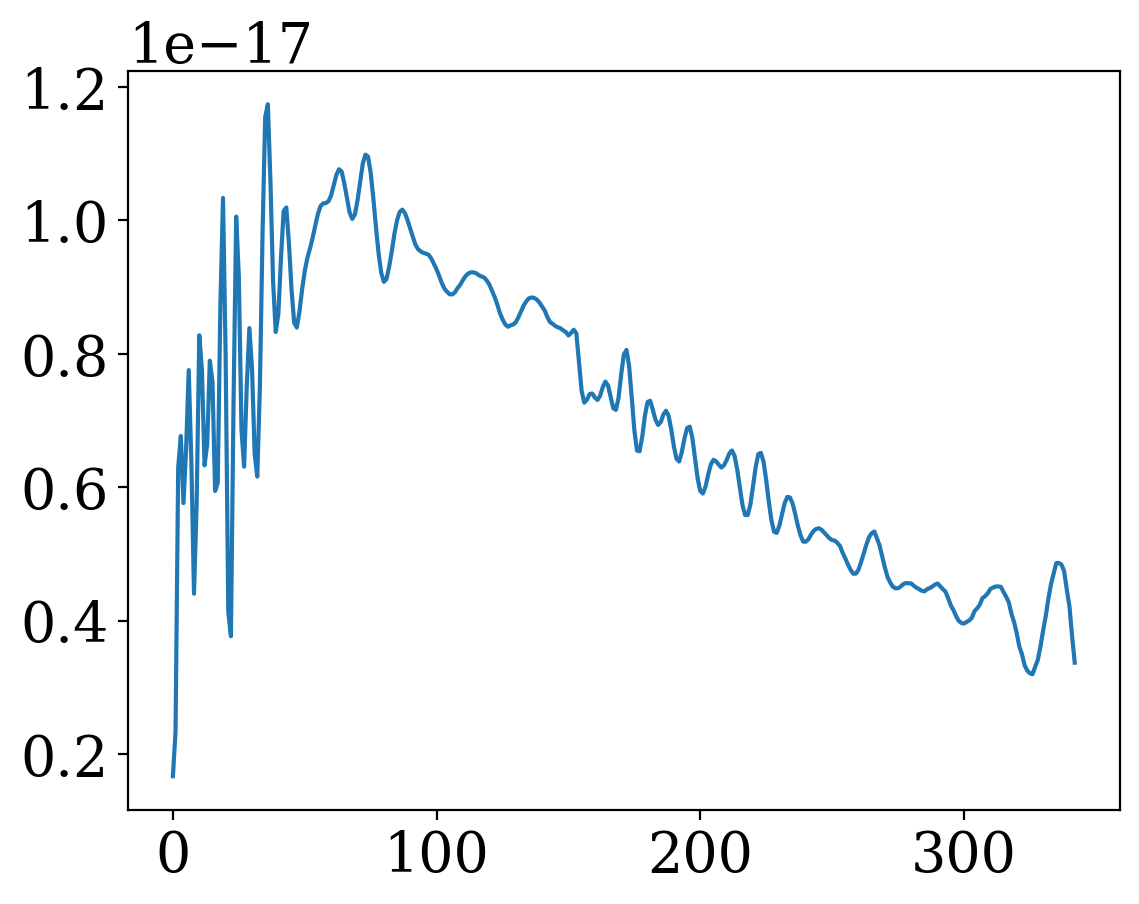

In [112]:
plt.plot(calibrated_spectra['flux'].iloc[0])

In [149]:
import numpy as np

sampling = np.geomspace(330, 1049.9999999999, 361)
calibrated_spectra_geom, sampling = calibrate(f, sampling=sampling)

Text(0.5, 0, 'Wavelength [Å]')

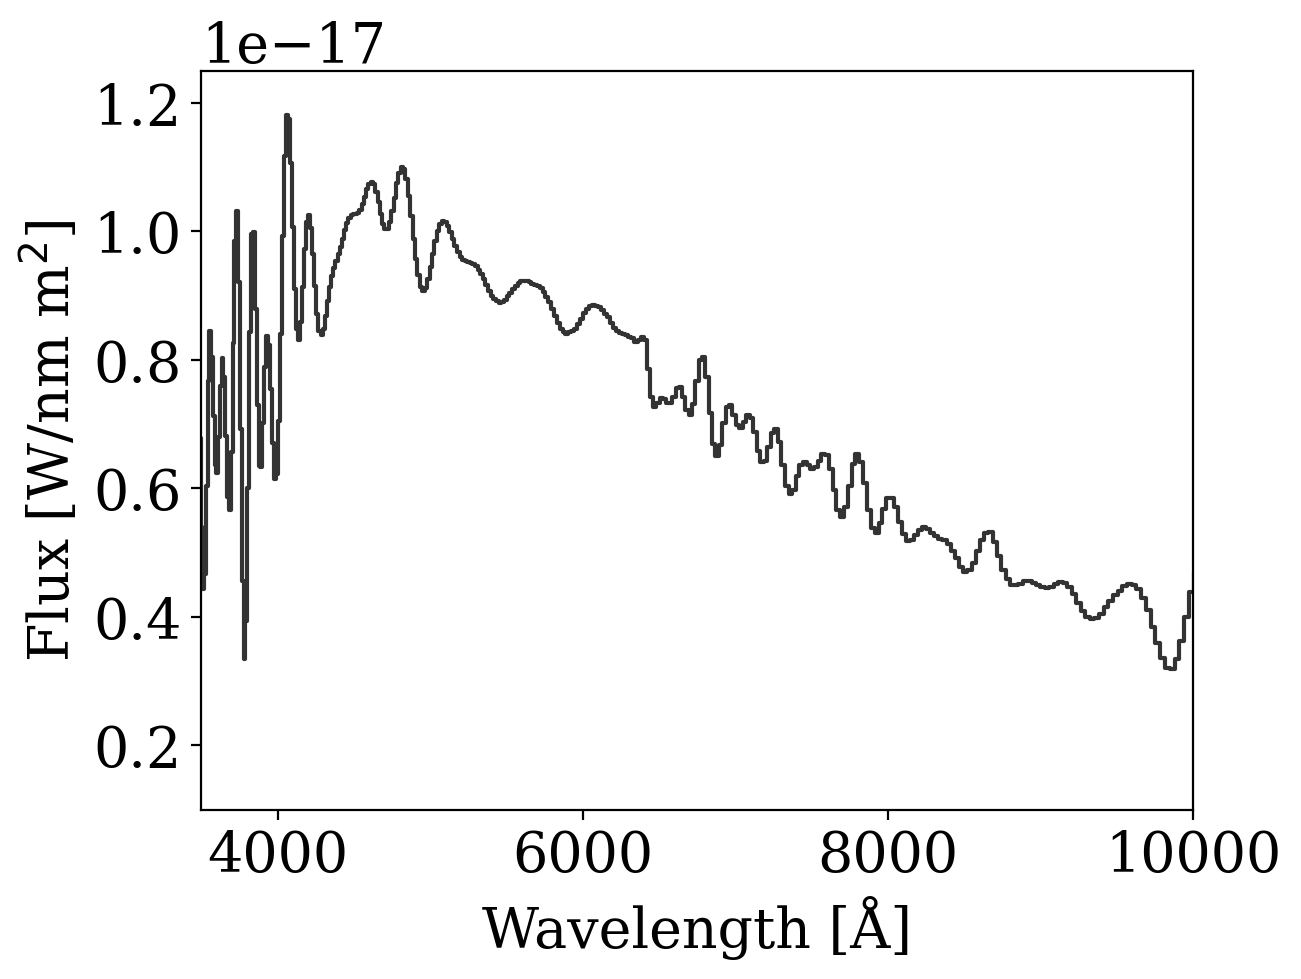

In [162]:
plt.step(sampling*10, calibrated_spectra_geom.flux.iloc[0], 
        color='#333333')
plt.xlim(350*10, 1_000*10)
plt.ylim(01e-18, 1.25e-17)

plt.ylabel("Flux [W/nm m$^2$]")
plt.xlabel("Wavelength [Å]")


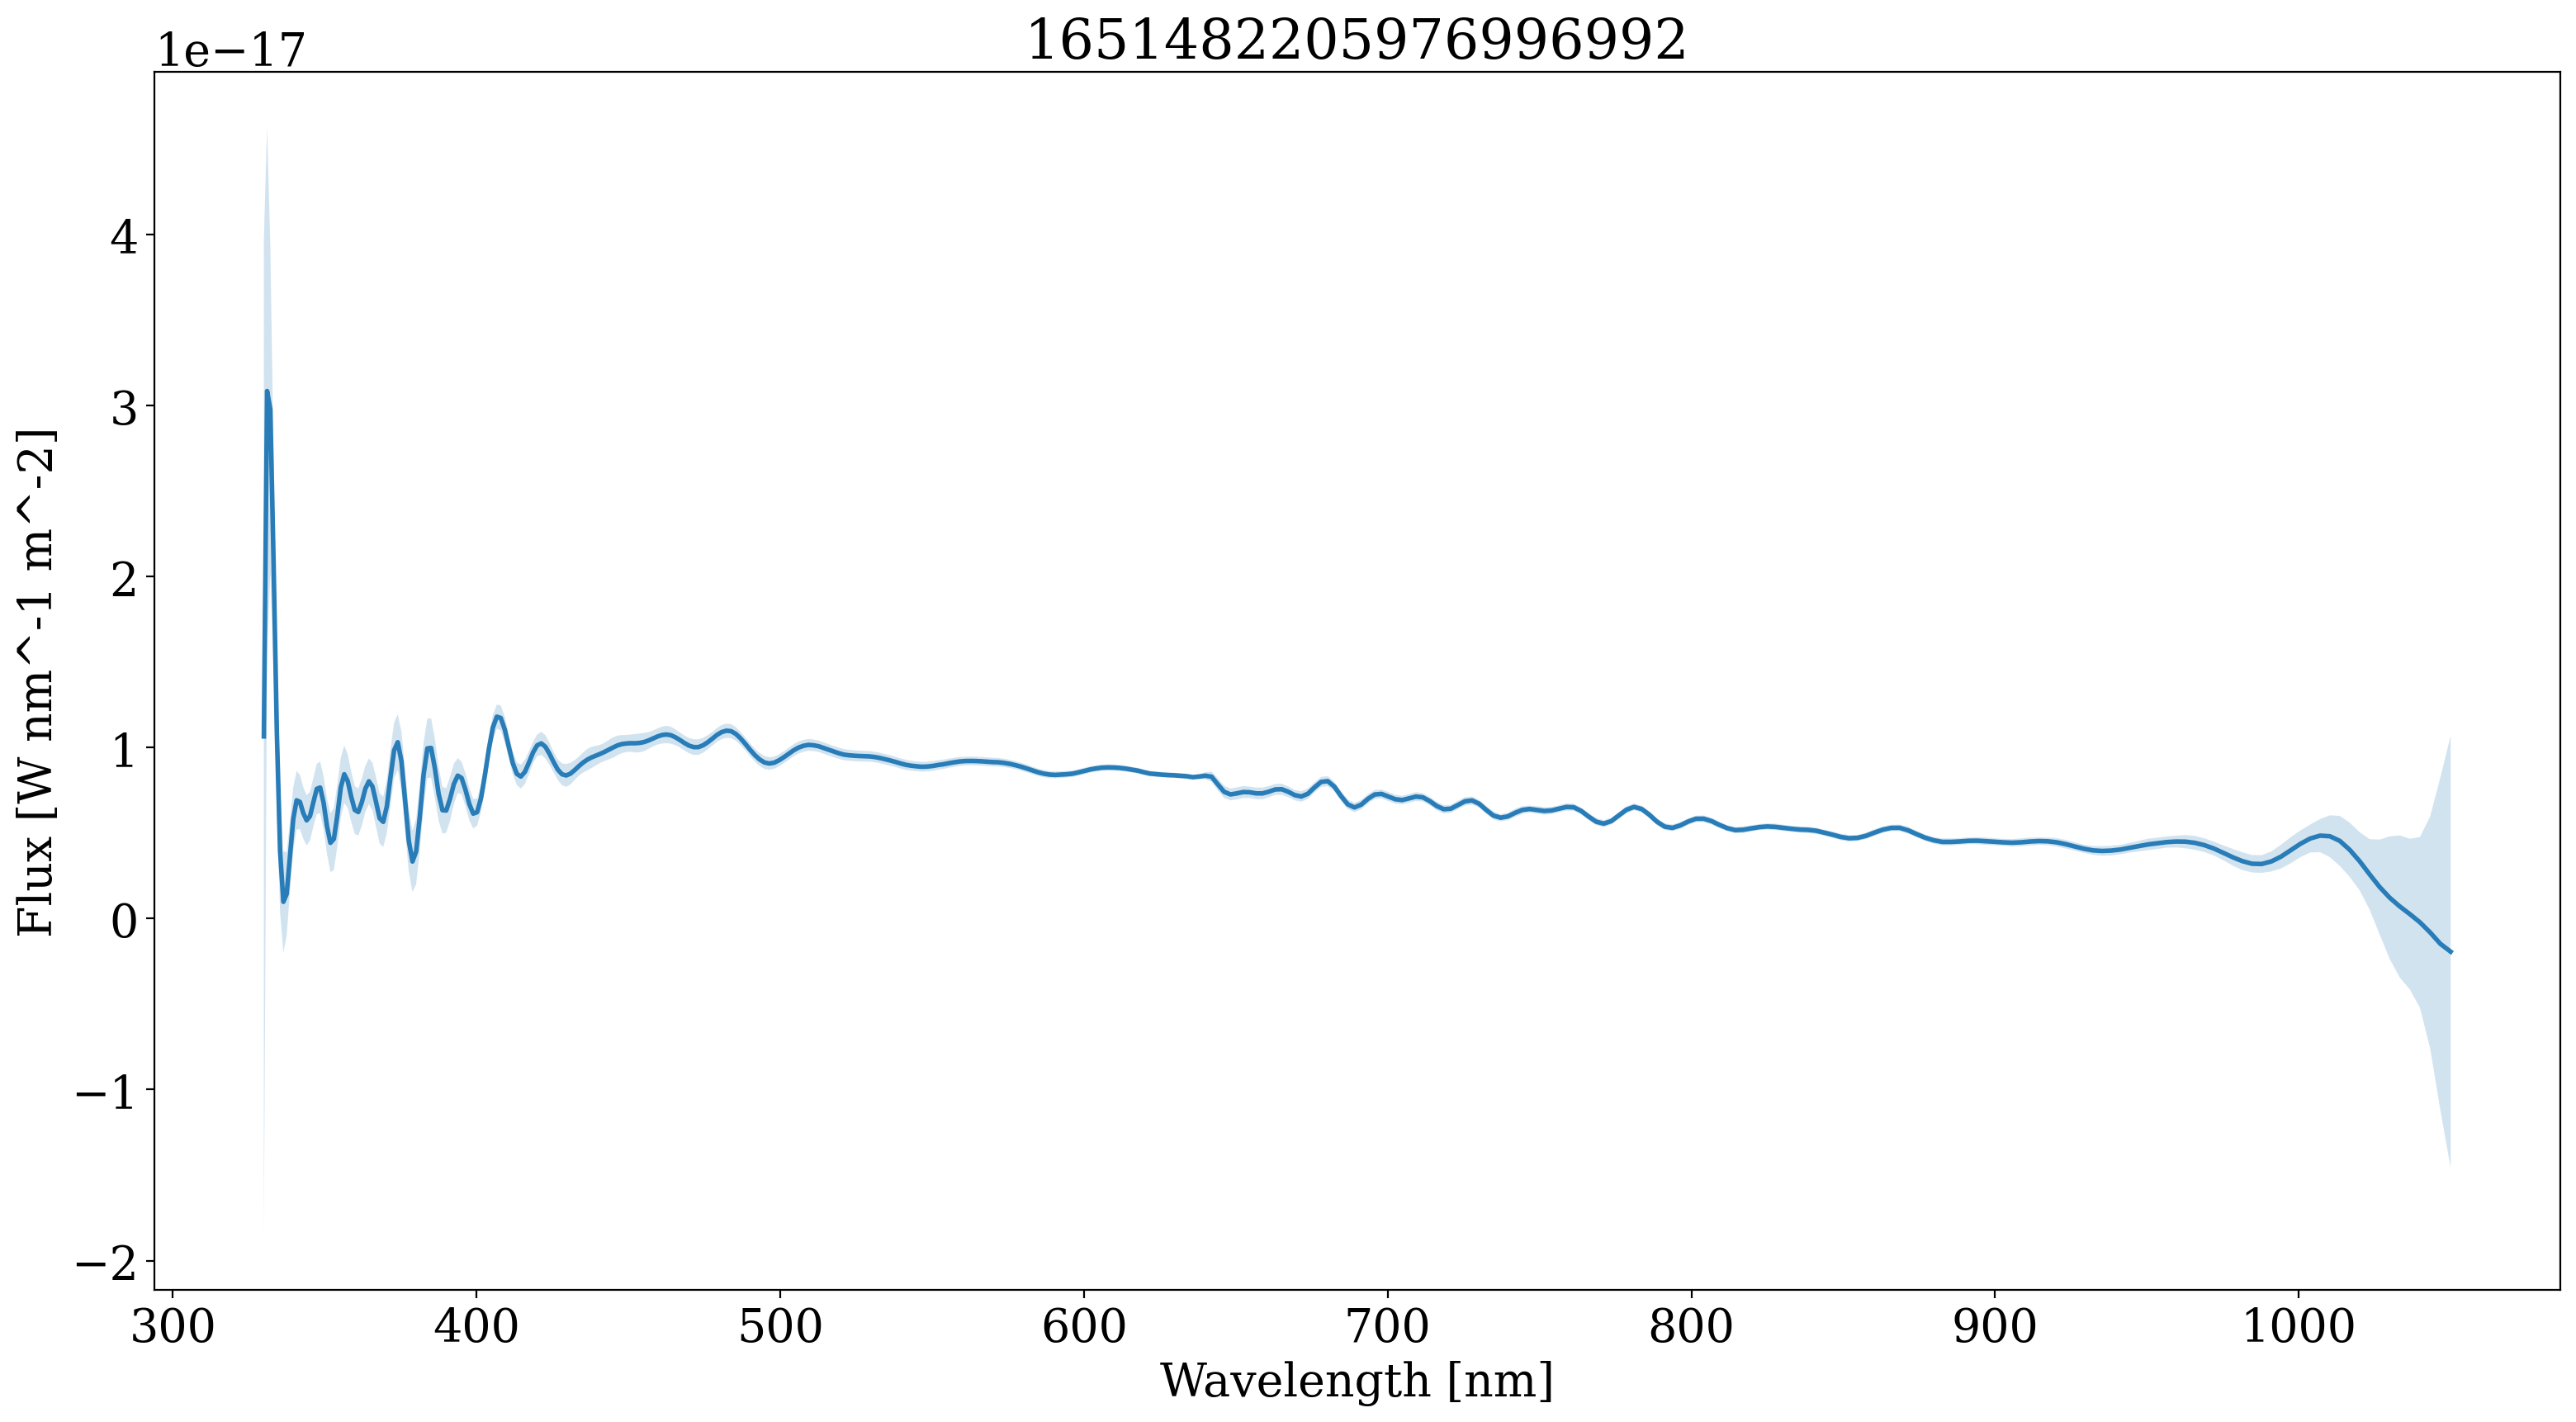

In [148]:
plot_spectra(calibrated_spectra_geom, sampling=sampling, legend=False)

In [96]:
from astropy.io import ascii
import pandas as pd
import dask

In [91]:
%%time
tbl = ascii.read("https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?ID=686103400034440&ID=686103400106565&BAD_CATFLAGS_MASK=32768&FORMAT=csv")

CPU times: user 88.2 ms, sys: 17.7 ms, total: 106 ms
Wall time: 2.69 s


In [95]:
%%time
pd.read_csv("https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?ID=686103400034440&ID=686103400106565&BAD_CATFLAGS_MASK=32768&FORMAT=csv")

CPU times: user 45 ms, sys: 21.5 ms, total: 66.5 ms
Wall time: 2.78 s


,oid,expid,hjd,mjd,mag,magerr,catflags,filtercode,ra,dec,...,ccdid,qid,limitmag,magzp,magzprms,clrcoeff,clrcounc,exptime,airmass,programid
0,686103400034440,45051390,2.458205e+06,58204.513901,17.723806,0.029264,0,zg,298.002521,29.871492,...,0x3,0x4,20.580000,26.380344,0.024219,-0.109300,0.000011,30,1.261,1
1,686103400034440,45151402,2.458206e+06,58205.514028,17.660419,0.028663,0,zg,298.002555,29.871463,...,0x3,0x4,20.969999,26.307392,0.018130,-0.060876,0.000006,30,1.247,1
2,686103400034440,45251668,2.458207e+06,58206.516690,17.659370,0.028654,0,zg,298.002536,29.871453,...,0x3,0x4,20.389999,26.109283,0.018583,-0.060469,0.000006,30,1.222,1
3,686103400034440,45252553,2.458207e+06,58206.525532,17.648050,0.028550,0,zg,298.002556,29.871470,...,0x3,0x4,20.740000,26.333904,0.017060,-0.061754,0.000006,30,1.186,1
4,686103400034440,45350884,2.458208e+06,58207.508843,17.632879,0.028412,0,zg,298.002551,29.871461,...,0x3,0x4,20.170000,26.335695,0.022384,-0.048380,0.000009,30,1.246,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,686103400106565,248314156,2.460238e+06,60237.141563,17.019510,0.024079,0,zg,298.003751,29.870621,...,0x3,0x4,21.230000,26.448278,0.018856,-0.080393,0.000007,30,1.064,1
1196,686103400106565,248516186,2.460240e+06,60239.161863,17.060070,0.024303,0,zg,298.003765,29.870630,...,0x3,0x4,20.840000,26.531046,0.019795,-0.123988,0.000007,30,1.129,1
1197,686103400106565,248814009,2.460243e+06,60242.140093,17.037785,0.024179,0,zg,298.003756,29.870627,...,0x3,0x4,20.570000,26.451742,0.017859,-0.090795,0.000006,30,1.091,1
1198,686103400106565,249112438,2.460246e+06,60245.124387,17.027718,0.024124,0,zg,298.003759,29.870636,...,0x3,0x4,20.030001,26.472630,0.021781,-0.093933,0.000009,30,1.074,1


## Try in Parallel

In [130]:
!pwd 

/Users/andytzanidakis/Desktop


In [133]:
def download_ZTF_parallel_v2(ID, ID2, MSK=32768):
    link = f"https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?ID={ID}&ID={ID2}&BAD_CATFLAGS_MASK={MSK}&FORMAT=csv"
    table = pd.read_csv(link)
    table.to_parquet(f"/Users/andytzanidakis/Desktop/test2/lc-{ID}.parquet",engine='pyarrow')

    
with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
    results = list(executor.map(download_ZTF_parallel_v2,
                                ids1, ids2))

In [134]:
%%time
with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
    # Use map to apply the function to each set of coordinates in parallel
    results = list(executor.map(download_ZTF_parallel_v2, ids1, ids2))

CPU times: user 1.19 s, sys: 141 ms, total: 1.33 s
Wall time: 15.4 s


In [99]:
import dask.dataframe as dd

In [103]:
%%time
at = dd.read_csv("https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?ID=686103400034440&ID=686103400106565&BAD_CATFLAGS_MASK=32768&FORMAT=csv",
           blocksize=None)

CPU times: user 52.7 ms, sys: 8.42 ms, total: 61.1 ms
Wall time: 6.56 s


In [135]:
import os

In [137]:
%%time
os.system("wget https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?ID=686103400034440&ID=686103400106565&BAD_CATFLAGS_MASK=32768&FORMAT=csv")

CPU times: user 1.32 ms, sys: 2.82 ms, total: 4.14 ms
Wall time: 25.5 ms


0

--2024-02-28 15:04:52--  https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?ID=686103400034440
Resolving irsa.ipac.caltech.edu (irsa.ipac.caltech.edu)... 134.4.54.87
Connecting to irsa.ipac.caltech.edu (irsa.ipac.caltech.edu)|134.4.54.87|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/xml]
Saving to: ‘nph_light_curves?ID=686103400034440.1’

     0K .......... .......... .......... .......... ..........  393K
    50K .......... .......... .......... .......... ..........  417K
   100K .......... .......... .......... .......... ..........  424K
   150K .......... .......... .......... .......... ..........  481K
   200K .......... .......... .......... .......... ..........  556K
   250K .......... .......... .......... .......... ..........  631K
   300K .......... .......... .......... .......... ..........  649K
   350K .......... .......... .......... .......... ..........  657K
   400K .......... .......... .......... .......... .

In [142]:
def dow_os(i):
    os.system(f"wget lc-{i}.csv https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?ID=686103400034440&ID=686103400106565&BAD_CATFLAGS_MASK=32768&FORMAT=csv")


In [145]:

%%time
i = np.zeros(10)

with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
    # Use map to apply the function to each set of coordinates in parallel
    results = list(executor.map(dow_os, i))

CPU times: user 5.81 ms, sys: 10.2 ms, total: 16 ms
Wall time: 144 ms


--2024-02-28 15:07:23--  https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?ID=686103400034440
--2024-02-28 15:07:23--  https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?ID=686103400034440
Resolving irsa.ipac.caltech.edu (irsa.ipac.caltech.edu)... 134.4.54.87
Connecting to irsa.ipac.caltech.edu (irsa.ipac.caltech.edu)|134.4.54.87|:443... Resolving irsa.ipac.caltech.edu (irsa.ipac.caltech.edu)... 134.4.54.87
Connecting to irsa.ipac.caltech.edu (irsa.ipac.caltech.edu)|134.4.54.87|:443... --2024-02-28 15:07:23--  https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?ID=686103400034440
Resolving irsa.ipac.caltech.edu (irsa.ipac.caltech.edu)... 134.4.54.87
Connecting to irsa.ipac.caltech.edu (irsa.ipac.caltech.edu)|134.4.54.87|:443... --2024-02-28 15:07:23--  https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?ID=686103400034440
Resolving irsa.ipac.caltech.edu (irsa.ipac.caltech.edu)... 134.4.54.87
Connecting to irsa.ipac.caltech.edu (irsa.ipac.caltech.edu)|134.

   400K .................. .......... .. .......... .... .............. .... .................. .......... ........... .......... .... ................... ...  593K...
   400K ..........  612K
   300K ............ ..........  613K
   400K ........  403K
   400K .......... .......... .......... ............. ..... .................. 1.06M
   450K .......... ..........  604K
   400K. ...................... .......... .......... 1.09M
   450K ... .......... ............  589K
   500K .......... .......... ....... .......... ....... ...... ........... ...................... .......... .............. .......... ........... .... .............. .... .................. 1.23M
   450K .. .......... .......... ............ .......... ............ .......... ............... .......... ...        1.04M=0.9s

2024-02-28 15:07:25 (600 KB/s) - ‘nph_light_curves?ID=686103400034440.4.1’ saved [556963]

.. .... .  387K.
   400K .................... ........ .......... ..............  657K
   450K .......

In [ ]:
https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?ID=686103400034440&ID=686103400106565,686103400106565&BAD_CATFLAGS_MASK=32768&FORMAT=HTML

In [168]:
%%time
t1 = pd.read_csv("https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?ID=686103400034440&BAD_CATFLAGS_MASK=32768&FORMAT=csv")

CPU times: user 24.6 ms, sys: 31.7 ms, total: 56.3 ms
Wall time: 1.46 s


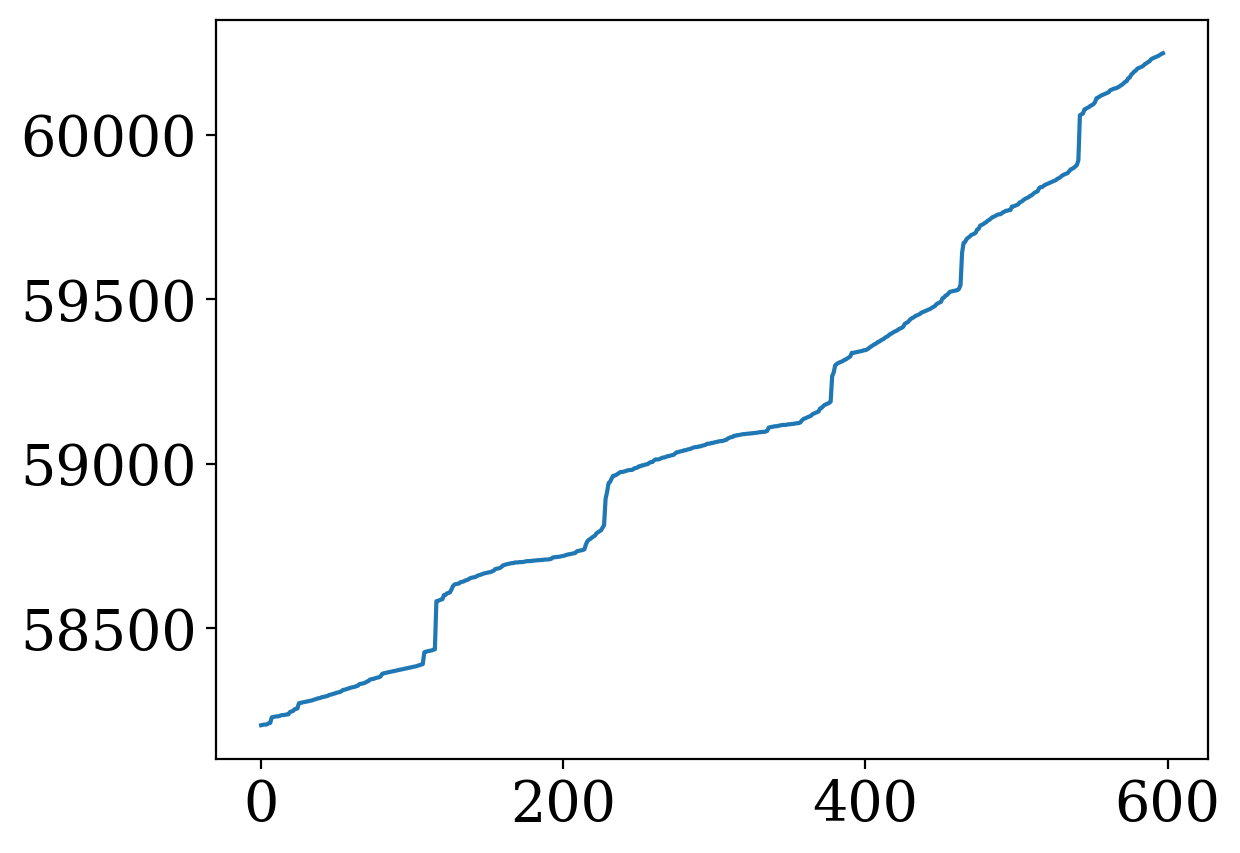

In [169]:
plt.plot(t1['mjd'])

In [236]:
strs = ["&ID=686103400034440" for _ in range(30)]

In [237]:
final = ""
for f in strs:
    final += f

In [238]:
final[1::]

'ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440'

In [239]:
part_1 = "https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?"
part_end = "&BAD_CATFLAGS_MASK=32768&FORMAT=csv"

In [240]:
part_1 + final[1::] + part_end

'https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&BAD_CATFLAGS_MASK=32768&FORMAT=csv'

In [241]:
%%time
s = pd.read_csv(part_1 + final[1::] + part_end)

CPU times: user 103 ms, sys: 54.2 ms, total: 158 ms
Wall time: 30 s


In [242]:
s

,oid,expid,hjd,mjd,mag,magerr,catflags,filtercode,ra,dec,...,ccdid,qid,limitmag,magzp,magzprms,clrcoeff,clrcounc,exptime,airmass,programid
0,686103400034440,45051390,2.458205e+06,58204.513901,17.723806,0.029264,0,zg,298.002521,29.871492,...,0x3,0x4,20.580000,26.380344,0.024219,-0.109300,0.000011,30,1.261,1
1,686103400034440,45151402,2.458206e+06,58205.514028,17.660419,0.028663,0,zg,298.002555,29.871463,...,0x3,0x4,20.969999,26.307392,0.018130,-0.060876,0.000006,30,1.247,1
2,686103400034440,45251668,2.458207e+06,58206.516690,17.659370,0.028654,0,zg,298.002536,29.871453,...,0x3,0x4,20.389999,26.109283,0.018583,-0.060469,0.000006,30,1.222,1
3,686103400034440,45252553,2.458207e+06,58206.525532,17.648050,0.028550,0,zg,298.002556,29.871470,...,0x3,0x4,20.740000,26.333904,0.017060,-0.061754,0.000006,30,1.186,1
4,686103400034440,45350884,2.458208e+06,58207.508843,17.632879,0.028412,0,zg,298.002551,29.871461,...,0x3,0x4,20.170000,26.335695,0.022384,-0.048380,0.000009,30,1.246,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17935,686103400034440,248314156,2.460238e+06,60237.141563,17.691517,0.028954,0,zg,298.002527,29.871464,...,0x3,0x4,21.230000,26.448278,0.018856,-0.080393,0.000007,30,1.064,1
17936,686103400034440,248516186,2.460240e+06,60239.161863,17.787813,0.029904,0,zg,298.002569,29.871453,...,0x3,0x4,20.840000,26.531046,0.019795,-0.123988,0.000007,30,1.129,1
17937,686103400034440,248814009,2.460243e+06,60242.140093,17.708809,0.029119,0,zg,298.002513,29.871471,...,0x3,0x4,20.570000,26.451742,0.017859,-0.090795,0.000006,30,1.091,1
17938,686103400034440,249112438,2.460246e+06,60245.124387,17.743534,0.029457,0,zg,298.002511,29.871483,...,0x3,0x4,20.030001,26.472630,0.021781,-0.093933,0.000009,30,1.074,1


In [243]:
import concurrent.futures

# Function to read CSV given a URL
def read_csv(url):
    return pd.read_csv(url)

# Number of workers
num_workers = 3

# List of strings
strs = ["&ID=686103400034440" for _ in range(30)]

# Concatenate the strings to form the final URL
final = "".join(strs)

# Part 1 and Part End of the URL
part_1 = "https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?"
part_end = "&BAD_CATFLAGS_MASK=32768&FORMAT=csv"

# Create a list of URLs
urls = [part_1 + final[i+1:i+32] + part_end for i in range(0, len(final), 32)]

# Function to read CSV using threads
def process_url(url):
    return pd.read_csv(url)

# Use ThreadPoolExecutor to parallelize the CSV reading
with concurrent.futures.ThreadPoolExecutor(max_workers=num_workers) as executor:
    results = list(executor.map(process_url, urls))

HTTPError: HTTP Error 400: Bad Request

In [284]:
%%time

import pandas as pd
import concurrent.futures

# Function to read CSV given a URL
def read_csv(url):
    return pd.read_csv(url)

# Number of workers
num_workers = 10

# List of strings
strs = ["&ID=686103400034440" for _ in range(100)]

# Concatenate the strings to form the final URL
final = "".join(strs)

# Part 1 and Part End of the URL
part_1 = "https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?"
part_end = "&BAD_CATFLAGS_MASK=32768&FORMAT=csv"

# Create a list of URLs
urls = [part_1 + final[1::] + part_end for i in range(0,10)]

# Print the URLs for troubleshooting
for url in urls:
    print(url)

# Function to read CSV using threads
def process_url(url):
    try:
        return pd.read_csv(url)
    except Exception as e:
        print(f"Error fetching data from {url}: {e}")
        return None

https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=686103400034440&ID=6861034

In [285]:
%%time
# Use ThreadPoolExecutor to parallelize the CSV reading
with concurrent.futures.ThreadPoolExecutor(max_workers=num_workers) as executor:
    results = list(executor.map(process_url, urls))

CPU times: user 1.64 s, sys: 983 ms, total: 2.63 s
Wall time: 1min 46s


In [283]:
results[0]

,oid,expid,hjd,mjd,mag,magerr,catflags,filtercode,ra,dec,...,ccdid,qid,limitmag,magzp,magzprms,clrcoeff,clrcounc,exptime,airmass,programid
0,686103400034440,45051390,2.458205e+06,58204.513901,17.723806,0.029264,0,zg,298.002521,29.871492,...,0x3,0x4,20.580000,26.380344,0.024219,-0.109300,0.000011,30,1.261,1
1,686103400034440,45151402,2.458206e+06,58205.514028,17.660419,0.028663,0,zg,298.002555,29.871463,...,0x3,0x4,20.969999,26.307392,0.018130,-0.060876,0.000006,30,1.247,1
2,686103400034440,45251668,2.458207e+06,58206.516690,17.659370,0.028654,0,zg,298.002536,29.871453,...,0x3,0x4,20.389999,26.109283,0.018583,-0.060469,0.000006,30,1.222,1
3,686103400034440,45252553,2.458207e+06,58206.525532,17.648050,0.028550,0,zg,298.002556,29.871470,...,0x3,0x4,20.740000,26.333904,0.017060,-0.061754,0.000006,30,1.186,1
4,686103400034440,45350884,2.458208e+06,58207.508843,17.632879,0.028412,0,zg,298.002551,29.871461,...,0x3,0x4,20.170000,26.335695,0.022384,-0.048380,0.000009,30,1.246,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29895,686103400034440,248314156,2.460238e+06,60237.141563,17.691517,0.028954,0,zg,298.002527,29.871464,...,0x3,0x4,21.230000,26.448278,0.018856,-0.080393,0.000007,30,1.064,1
29896,686103400034440,248516186,2.460240e+06,60239.161863,17.787813,0.029904,0,zg,298.002569,29.871453,...,0x3,0x4,20.840000,26.531046,0.019795,-0.123988,0.000007,30,1.129,1
29897,686103400034440,248814009,2.460243e+06,60242.140093,17.708809,0.029119,0,zg,298.002513,29.871471,...,0x3,0x4,20.570000,26.451742,0.017859,-0.090795,0.000006,30,1.091,1
29898,686103400034440,249112438,2.460246e+06,60245.124387,17.743534,0.029457,0,zg,298.002511,29.871483,...,0x3,0x4,20.030001,26.472630,0.021781,-0.093933,0.000009,30,1.074,1


In [ ]:
# Concatenate the valid results if needed
result_df = pd.concat([result for result in results if result is not None], ignore_index=True)


In [306]:
%%time
tbl = ascii.read("https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&BAD_CATFLAGS_MASK=32768&FORMAT=ipac_table")

CPU times: user 132 ms, sys: 13.2 ms, total: 145 ms
Wall time: 6.03 s


In [308]:
%%time
tbl = pd.read_html("https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&BAD_CATFLAGS_MASK=32768&FORMAT=HTML")

CPU times: user 1.03 s, sys: 77.2 ms, total: 1.11 s
Wall time: 6.79 s


In [309]:
%%time
tbl = ascii.read("https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&BAD_CATFLAGS_MASK=32768&FORMAT=csv")

CPU times: user 119 ms, sys: 24.5 ms, total: 144 ms
Wall time: 5.34 s


In [310]:
%%time
tbl = pd.read_csv("https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves?ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&ID=660106400019009&BAD_CATFLAGS_MASK=32768&FORMAT=csv")

CPU times: user 53.2 ms, sys: 16.1 ms, total: 69.3 ms
Wall time: 5.29 s
